In [ ]:
import warnings
warnings.filterwarnings('ignore')

import os
import cv2
import numpy as np
from glob import glob
from tqdm import tqdm
from tensorflow.keras.layers import Dense, Conv2D, GlobalAveragePooling2D, MaxPooling2D,Flatten

In [ ]:
meta_path = r"C:\Users\X\Desktop\COMAAWCA\MUDRAS"
save_path = os.path.join(meta_path, "NPZs")
os.makedirs(save_path, exist_ok=True)

image_class = ["Apana","Dhyana","Gyana","Hakini","Prana",
               "Prithvi","Sambhala","Shunya","Vajra","Vayu"]

In [ ]:
def get_all_filenames_in_list(dirname):
    file_paths = []
    for root, directories, files in os.walk(dirname):
        for filename in files:
            if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
                filepath = os.path.join(root, filename)
                file_paths.append(filepath)
    return file_paths

def encode_class(class_name, class_names):
    try:
        idx = class_names.index(class_name)
        vec = np.zeros(len(class_names), dtype=np.float32)
        vec[idx] = 1
        return vec, idx
    except ValueError:
        return None, None

print("\n Class-wise encoding:")
for cls in image_class:
    vec, idx = encode_class(cls, image_class)
    print(f"\n {cls}: index={idx}, one-hot={vec}")


 Class-wise encoding:

 Apana: index=0, one-hot=[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

 Dhyana: index=1, one-hot=[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]

 Gyana: index=2, one-hot=[0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]

 Hakini: index=3, one-hot=[0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]

 Prana: index=4, one-hot=[0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]

 Prithvi: index=5, one-hot=[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]

 Sambhala: index=6, one-hot=[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]

 Shunya: index=7, one-hot=[0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]

 Vajra: index=8, one-hot=[0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]

 Vayu: index=9, one-hot=[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


In [ ]:
"""
all_image_files = get_all_filenames_in_list(meta_path)
print(f"found {len(all_image_files)} images")

for idx, file in enumerate((all_image_files)):
    try:
        image = cv2.imread(file)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (224, 224), interpolation=cv2.INTER_CUBIC)

        basepath, _ = os.path.split(file)
        _, label_name = os.path.split(basepath)

        target, class_idx = encode_class(label_name, image_class)

        if target is not None:
            npz_filename = os.path.join(save_path, f"img_{idx:05d}.npz")
            np.savez_compressed(npz_filename, image=image, label=target)
    except Exception as e:
        print(f"Error processing {file}: {e}")

print(f"saved {len(all_image_files)} images and corresponding labels as npz to {save_path}")
"""

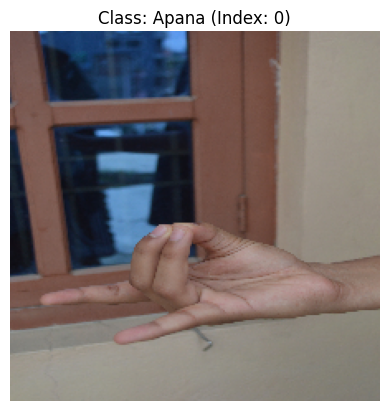

In [ ]:
#decoding-a-npz-file

import matplotlib.pyplot as plt

npz_file = r"C:\Users\X\Desktop\COMAAWCA\MUDRAS\NPZs\img_00000.npz"

data = np.load(npz_file)
image = data['image']
label = data['label']

image_class = ['Apana','Dhyana','Gyana','Hakini','Prana','Prithvi','Sambhala','Shunya','Vajra','Vayu']
class_idx = np.argmax(label)
class_name = image_class[class_idx]

plt.imshow(image)
plt.title(f"Class: {class_name} (Index: {class_idx})")
plt.axis('off')
plt.show()

In [ ]:
import numpy as np
import cv2
from tensorflow.keras.utils import Sequence

class CustomImageDataGenerator(Sequence):
    def __init__(self, file_list, batch_size=32, shuffle=True, augment=False):
        self.file_list = file_list
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.augment = augment
        self.indexes = np.arange(len(self.file_list))
        if self.shuffle:
            np.random.shuffle(self.indexes)

    def __len__(self):
        return int(np.ceil(len(self.file_list) / self.batch_size))

    def __getitem__(self, index):
        start_idx = index * self.batch_size
        end_idx = min((index + 1) * self.batch_size, len(self.file_list))
        batch_indexes = self.indexes[start_idx:end_idx]

        batch_images = []
        batch_labels = []

        for idx in batch_indexes:
            data = np.load(self.file_list[idx])
            image = data['image']
            label = data['label']

            if self.augment:
                image, _ = self._augment_image(image)

            image = image.astype(np.float32) / 255.0
            batch_images.append(image)
            batch_labels.append(label)

        return np.array(batch_images), np.array(batch_labels)

    def _augment_image(self, image):
        applied_augs = []

        #horizontalflip
        if np.random.rand() > 0.5:
            image = np.fliplr(image)
            applied_augs.append("Horizontal Flip")

        #rotation
        if np.random.rand() > 0.5:
            angle = np.random.uniform(-15, 15)
            h, w = image.shape[:2]
            M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
            image = cv2.warpAffine(image, M, (w, h))
            applied_augs.append(f"Rotation {angle:.1f}°")

        #verticalflip
        if np.random.rand() > 0.5:
            image = np.flipud(image)
            applied_augs.append("Vertical Flip")

        return image, ", ".join(applied_augs)

    def on_epoch_end(self):
        """shuffle indexes after each epoch if shuffle=True"""
        if self.shuffle:
            np.random.shuffle(self.indexes)


In [ ]:
from glob import glob
import numpy as np

npz_files = sorted(glob(r"C:\Users\X\Desktop\COMAAWCA\MUDRAS\NPZs\*.npz"))
print(f"found {len(npz_files)} .npz files")

np.random.seed(42)
np.random.shuffle(npz_files)

split = int(0.8 * len(npz_files))
train_gen = CustomImageDataGenerator(npz_files[:split], batch_size=32, shuffle=True,  augment=True)
val_gen   = CustomImageDataGenerator(npz_files[split:],  batch_size=32, shuffle=False, augment=False)

print(f"train batches: {len(train_gen)}")
print(f"val batches: {len(val_gen)}")

Found 1192 .npz files
train batches: 30
val batches: 8


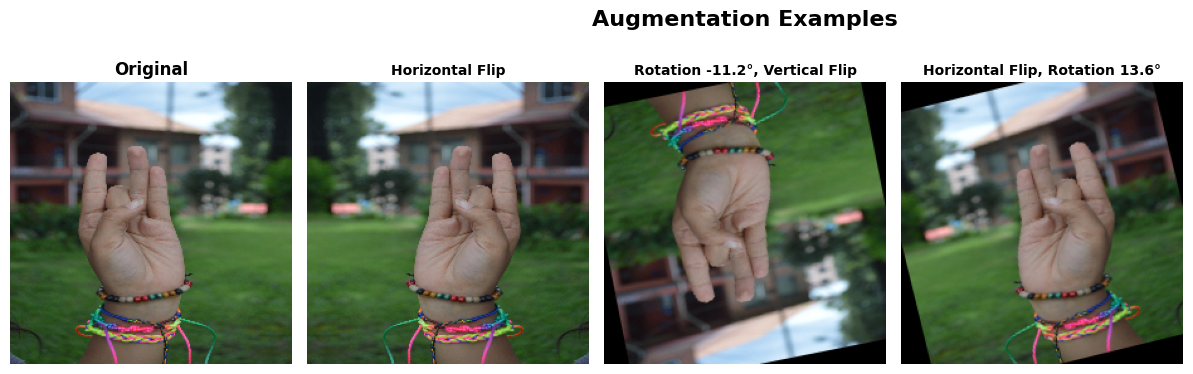

In [ ]:
import matplotlib.pyplot as plt

sample_npz_path = train_gen.file_list[0]
data = np.load(sample_npz_path)
original_img = data['image']

plt.figure(figsize=(15, 8))
for i in range(4):
    plt.subplot(2, 5, i + 1)
    if i == 0:
        plt.imshow(original_img)
        plt.title('Original', fontweight='bold', fontsize=12)
    else:
        aug_img, desc = train_gen._augment_image(original_img.copy())
        plt.imshow(aug_img.astype('uint8'))
        plt.title(desc if desc else "No Aug", fontsize=10, fontweight='bold')
    plt.axis('off')

plt.suptitle("Augmentation Examples", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization, Dropout, GlobalAveragePooling2D, Dense, Flatten
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

model = Sequential()
model.add(Conv2D(16, (3,3), padding='valid', activation='relu', input_shape=(224,224,3)))
model.add(MaxPooling2D((2,2)))
model.add(Conv2D(32, (3,3), padding='valid', activation='relu'))
model.add(MaxPooling2D((2,2)))
model.add(Conv2D(64, (3,3), padding='valid', activation='relu'))
model.add(MaxPooling2D((2,2)))
model.add(Conv2D(128, (3,3), padding='valid', activation='relu'))
model.add(MaxPooling2D((2,2)))
model.add(GlobalAveragePooling2D())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(10, activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    mode='min'
)

checkpoint = ModelCheckpoint(
    r'C:\Users\X\Desktop\COMAAWCA\MUDRAS\mudra.keras',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

history = model.fit(
    train_gen,
    epochs=150,
    validation_data=val_gen,
    callbacks=[early_stop, checkpoint]
)

best_val_loss = min(history.history['val_loss'])
best_epoch = history.history['val_loss'].index(best_val_loss)
best_val_accuracy = history.history['val_accuracy'][best_epoch]

print(f"best val Loss: {best_val_loss:.4f}")
print(f"best val accuracy: {best_val_accuracy:.4f}")


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,858 (479.91 KB)

 Trainable params: 122,858 (479.91 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.1096 - loss: 2.3013
Epoch 1: val_loss improved from None to 2.29420, saving model to C:\Users\X\Desktop\COMAAWCA\MUDRAS\mudra.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 105ms/step - accuracy: 0.1081 - loss: 2.3007 - val_accuracy: 0.1548 - val_loss: 2.2942
Epoch 2/150
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.1469 - loss: 2.2827
Epoch 2: val_loss improved from 2.29420 to 2.28510, saving model to C:\Users\X\Desktop\COMAAWCA\MUDRAS\mudra.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - accuracy: 0.1511 - loss: 2.2774 - val_accuracy: 0.1632 - val_loss: 2.2851
Epoch 3/150
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.1732 - loss: 2.2575
Epoch 3: val_loss improved from 2.28510 to 2.26818, saving model to C:\Users\X\Desktop\COMAAWCA\MUDRAS\mudra.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step - accuracy: 0.1574 - loss: 2.2585 - val_accuracy: 0.1757 - val_loss: 2.2682
Epoch 4/150
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step

In [ ]:
from tqdm import tqdm
import numpy as np

val_predictions = []
val_true_labels = []

for i in tqdm(range(len(val_gen)),desc= "Predicting on validation set"):
    batch_images, batch_labels = val_gen[i]
    preds = model.predict(batch_images, verbose=0)
    val_predictions.extend(np.argmax(preds, axis=1))
    val_true_labels.extend(np.argmax(batch_labels, axis=1))

val_predictions = np.array(val_predictions)
val_true_labels = np.array(val_true_labels)

Predicting on validation set: 100%|██████████| 8/8 [00:00<00:00, 10.93it/s]


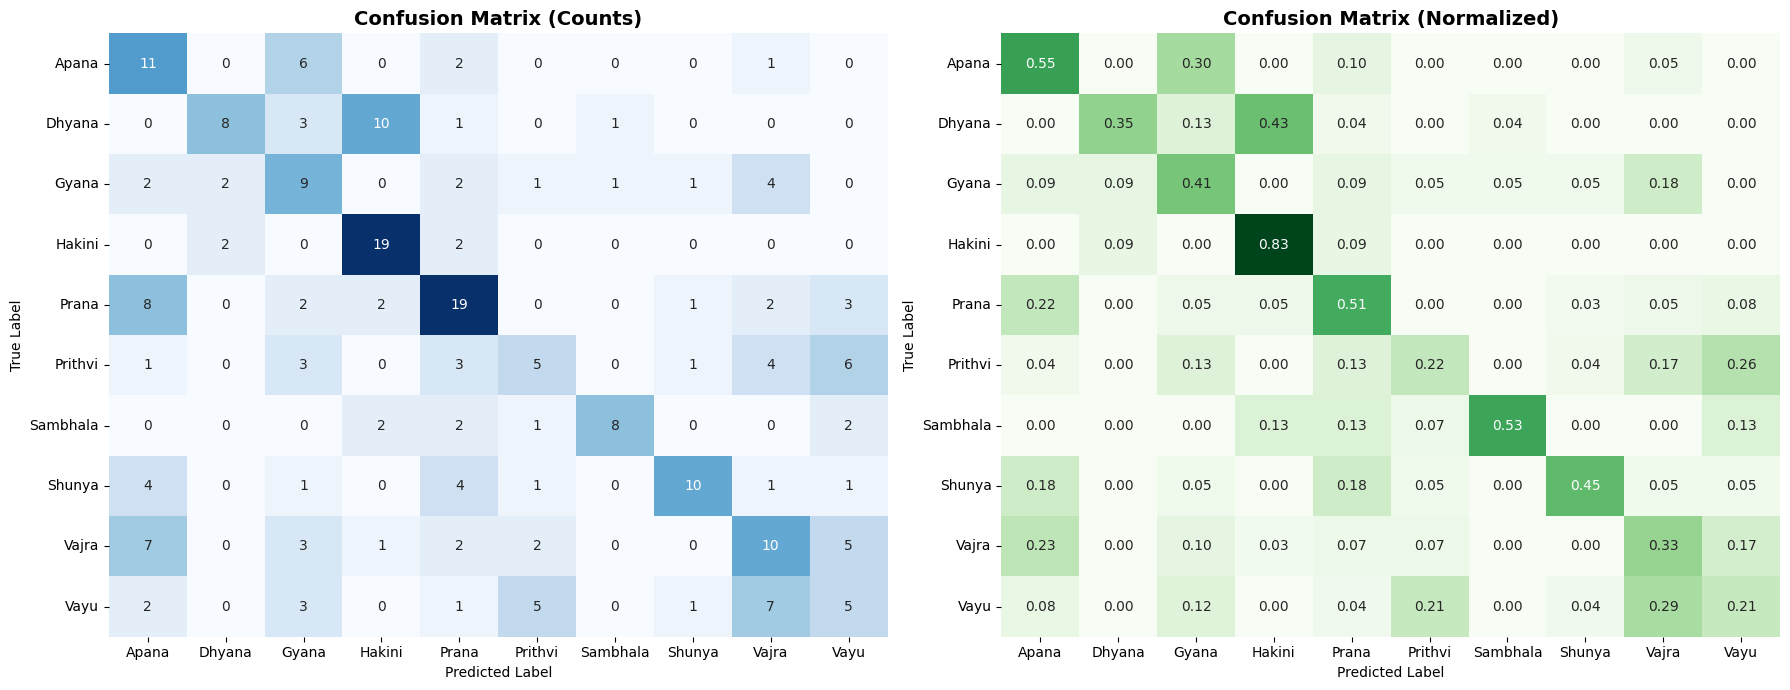

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

image_class = ["Apana","Dhyana","Gyana","Hakini","Prana",
               "Prithvi","Sambhala","Shunya","Vajra","Vayu"]

cm_raw = confusion_matrix(val_true_labels, val_predictions)
cm_norm = confusion_matrix(val_true_labels, val_predictions, normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(cm_raw, annot=True, fmt='d', cmap='Blues',
            xticklabels=image_class, yticklabels=image_class, ax=axes[0], cbar=False)
axes[0].set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=image_class, yticklabels=image_class, ax=axes[1], cbar=False)
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report

image_class = ["Apana","Dhyana","Gyana","Hakini","Prana",
               "Prithvi","Sambhala","Shunya","Vajra","Vayu"]

print("\nClassification Report:\n")
print(classification_report(val_true_labels, val_predictions,
                             target_names=image_class, digits=3))

model.save(os.path.join(meta_path, 'mudra.keras'))
print(f"\nModel saved as 'mudra.keras' at {meta_path}")


Classification Report:

              precision    recall  f1-score   support

       Apana      0.314     0.550     0.400        20
      Dhyana      0.667     0.348     0.457        23
       Gyana      0.300     0.409     0.346        22
      Hakini      0.559     0.826     0.667        23
       Prana      0.500     0.514     0.507        37
     Prithvi      0.333     0.217     0.263        23
    Sambhala      0.800     0.533     0.640        15
      Shunya      0.714     0.455     0.556        22
       Vajra      0.345     0.333     0.339        30
        Vayu      0.227     0.208     0.217        24

    accuracy                          0.435       239
   macro avg      0.476     0.439     0.439       239
weighted avg      0.463     0.435     0.433       239


Model saved as 'mudra.keras' at C:\Users\X\Desktop\COMAAWCA\MUDRAS


(1, 224, 224, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Predicted class: Gyana


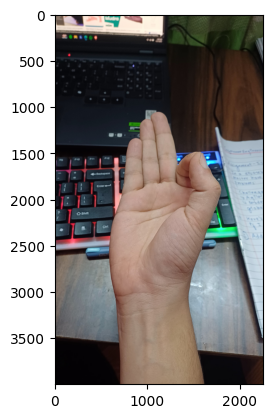

In [ ]:
test_img = cv2.cvtColor(cv2.imread(r"C:\Users\X\Desktop\COMAAWCA\samples\gyana.jpg"), cv2.COLOR_BGR2RGB)

plt.imshow(test_img)

model.load_weights(r"C:\Users\X\Desktop\COMAAWCA\MUDRAS\mudra.keras")
test_img = cv2.resize(test_img, (224, 224))
test_input = np.expand_dims(test_img, axis=0) / 255.0
print(test_input.shape)

#prediction
prediction = model.predict(test_input)
predicted_class = np.argmax(prediction)

#mapping-prediction-to-label
print("Predicted class:", image_class[predicted_class])